In [1]:
XENIUM_DATA_DIR = '/global/scratch/users/fosterangus/MetabTravLR/Data/Xenium'
DATASET_NAME = 'FF_Human_Ovarian_Adenocarcinoma'
DATA_DIR = f'{XENIUM_DATA_DIR}/{DATASET_NAME}'

In [2]:
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt

In [3]:
adata = sc.read_h5ad(f'{DATA_DIR}/adata.h5ad')
adata

AnnData object with n_obs × n_vars = 1157659 × 5001
    obs: 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', '_scvi_batch', '_scvi_labels', 'leiden_scVI_res_0.5', 'leiden_scVI_res_2.5', 'leiden_scVI_res_2', 'leiden_scVI_res_1.5', 'leiden_scVI_res_1', 'leiden_scVI_res_0.75', 'leiden_scVI_res_0.65', 'leiden_scVI_res_0.375', 'leiden_scVI_res_0.25', 'leiden_scVI_res_0.1', 'leiden_scVI_res_0.05'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'leiden_scVI_res_0.05', 'leiden_scVI_res_0.05_colors', 'leiden_scVI_res_0.1', 'leiden_scVI_res_0.1_colors', 'leiden_scVI_res_0.25', 'leiden_scVI_res_0.25_colors', 'leiden_scVI_res_0.375', 'leiden_scVI_res_0.375_colors', 'leiden_scVI_res_0.5', 'leiden_scVI_res_0.5_colors', 'leiden_scVI_res_0

/tmp/ipykernel_2494056/12019399.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, spot_size=5, show=False, title=DATASET_NAME, color='leiden_scVI_res_0.5');


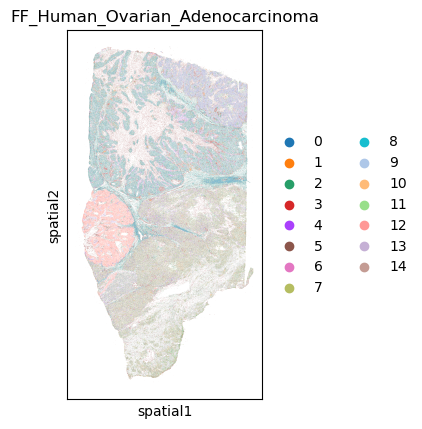

In [4]:
sc.pl.spatial(adata, spot_size=5, show=False, title=DATASET_NAME, color='leiden_scVI_res_0.5');

In [5]:
# Make sure counts layer exists
if 'counts' not in adata.layers:
    adata.layers['counts'] = adata.X.copy()

# Build log_norm layer from counts if it doesn't exist
if 'log_norm' not in adata.layers:
    adata.X = adata.layers['counts'].copy()
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    adata.layers['log_norm'] = adata.X.copy()
    # Restore raw counts to X
    adata.X = adata.layers['counts'].copy()

print("Layers available:", list(adata.layers.keys()))
print("X max (should be large if raw counts):", adata.X.max())
print("log_norm max (should be small, ~log scale):", adata.layers['log_norm'].max())

/tmp/ipykernel_2494056/1663927226.py:8: UserWarning: Some cells have zero counts
  sc.pp.normalize_total(adata, target_sum=1e4)


: 

In [ ]:
# resolutions = [2.5, 2, 1.5, 1, 0.75, 0.65, 0.5, 0.375, 0.25, 0.1, 0.05]
resolutions = [2.5, 2, 1.5, 1, 0.75, 0.65, 0.5]
def res_label(res):
    return f'leiden_scVI_res_{res}'
res_labels = [res_label(res) for res in resolutions]

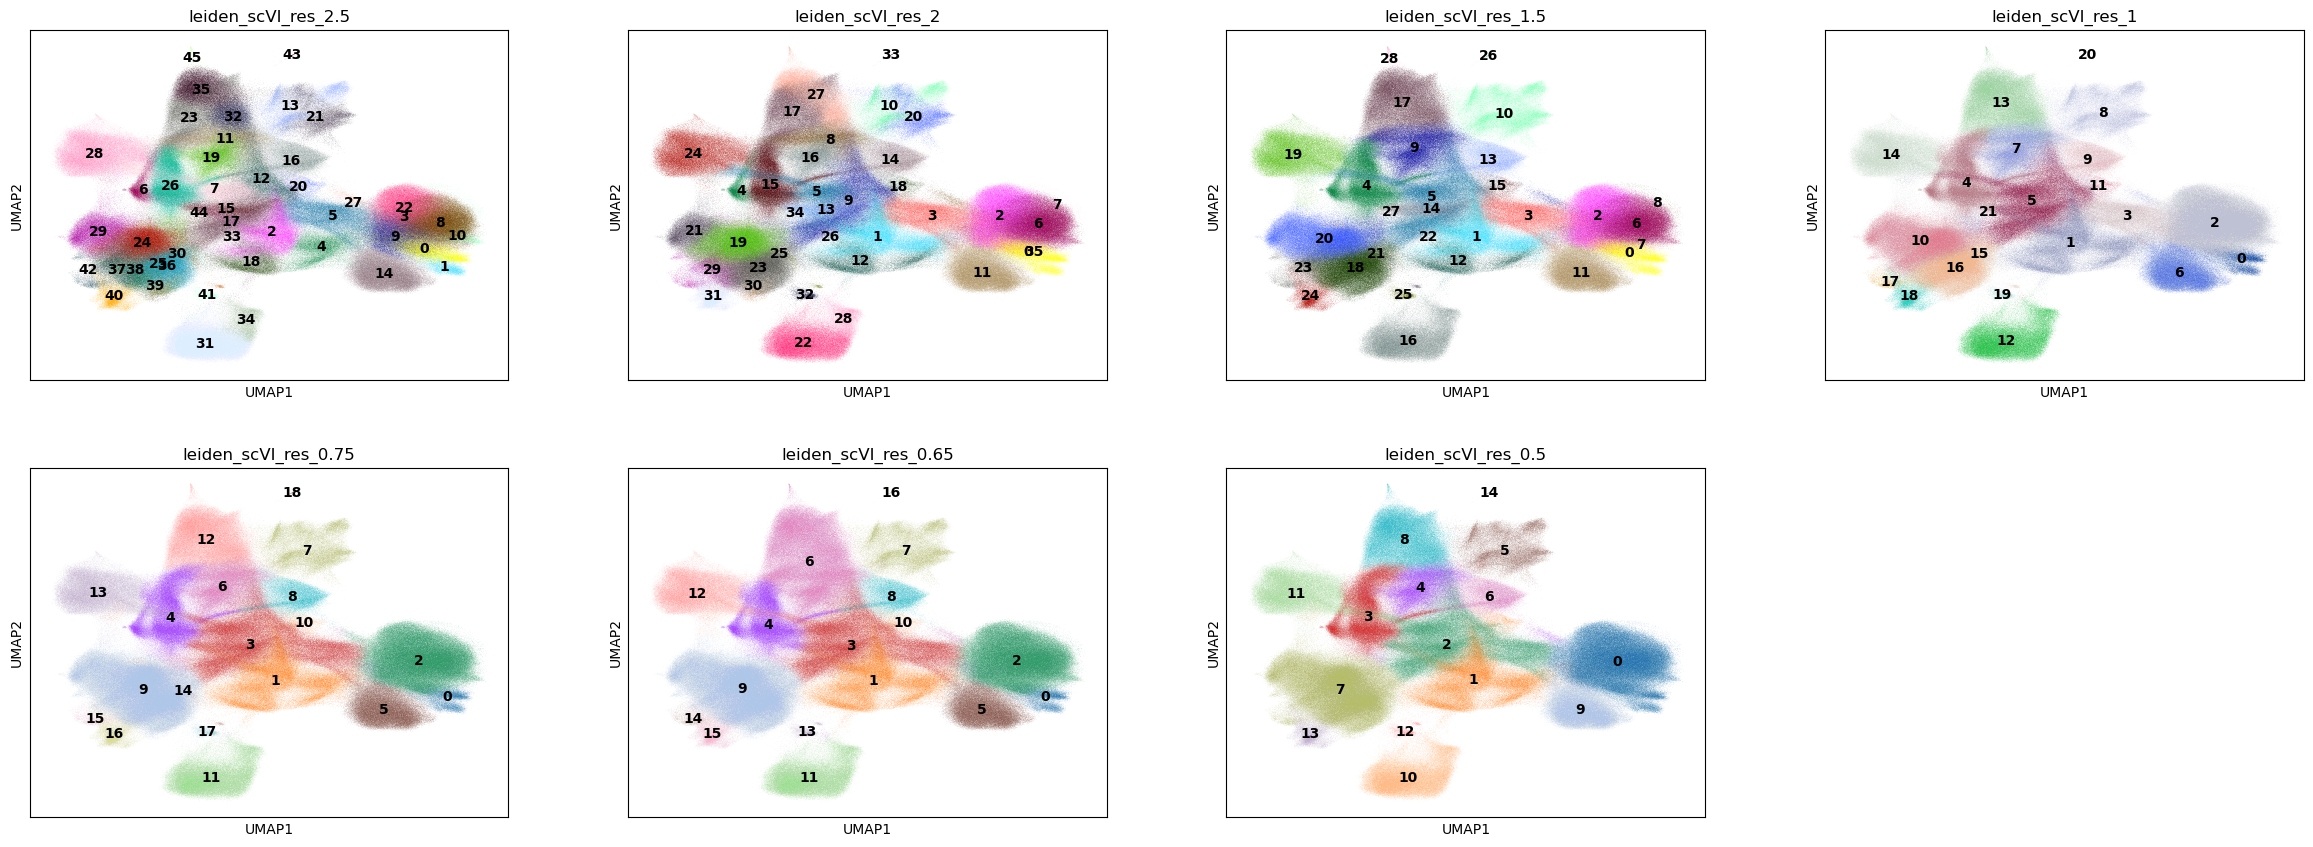

In [ ]:
sc.pl.umap(adata, color=res_labels, legend_loc="on data")


RESOLUTION: leiden_scVI_res_2.5


/global/home/users/fosterangus/.conda/envs/scvi/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:458: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
/global/home/users/fosterangus/.conda/envs/scvi/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:460: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
/global/home/users/fosterangus/.conda/envs/scvi/lib/python3.12/site-packages/scanpy/t


--- Top DE genes per cluster (log_norm) ---
Cluster 0: ['PVT1', 'OGT', 'ITGB4', 'BTN3A1', 'AR', 'TAP1', 'TAP2', 'NPR1', 'PTPRF', 'CFB', 'KLK10', 'MSLN', 'TBRG4', 'PDIA3', 'DHCR24']
Cluster 1: ['ADAMTS1', 'IRAK1', 'APEX1', 'CDH6', 'PVT1', 'EEF1G', 'DHCR24', 'KLHL14', 'ATP5F1A', 'DEPTOR', 'GHITM', 'SOX17', 'METTL3', 'OGT', 'MYC']
Cluster 2: ['CD3E', 'ITGAL', 'IL2RG', 'ACAP1', 'CXCR3', 'IL2RB', 'CD247', 'CD2', 'ZAP70', 'ITGB2', 'CD44', 'RASGRP1', 'LAG3', 'CD4', 'JAK3']
Cluster 3: ['DEPTOR', 'SQLE', 'TNFRSF14', 'ITGB4', 'NDRG1', 'GAS6', 'CFB', 'APOL2', 'MLPH', 'EEF1G', 'LGMN', 'PTPRU', 'ATP1A1', 'IRAK1', 'PVT1']
Cluster 4: ['CD3E', 'IL2RB', 'IL2RG', 'SEMA4D', 'CD247', 'ACAP1', 'ITGAL', 'ADGRE5', 'ZAP70', 'TNFRSF18', 'CD7', 'TAP1', 'CXCR3', 'GZMA', 'GBP5']
Cluster 5: ['ITGB2', 'CYBB', 'CD4', 'SLCO2B1', 'CSF1R', 'GRN', 'SIGLEC1', 'CD14', 'STAB1', 'MAN2B1', 'CD68', 'MSR1', 'SLC7A7', 'MMP9', 'FCGR2A']
Cluster 6: ['STMN2', 'ARG1', 'CYP2A6', 'SLC2A2', 'PLG', 'C9', 'C8B', 'AHSG', 'DCT', 'AFM', '

/tmp/ipykernel_1118701/436896345.py:49: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_scores = adata.obs.groupby(groupby_key)[score_cols].mean()
/tmp/ipykernel_1118701/436896345.py:51: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_scores['cell_count'] = adata.obs.groupby(groupby_key).size()



--- Marker set scores and cell counts per cluster (log_norm) ---
                     Cytotoxic_CD8_score  Exhausted_CD8_score  Treg_score  \
leiden_scVI_res_2.5                                                         
0                              -0.061183            -0.169934   -0.178279   
1                              -0.072784            -0.181746   -0.177347   
2                               0.632503             0.692083    0.844535   
3                              -0.058840            -0.163749   -0.182743   
4                               0.638500             0.539963    0.470052   
5                              -0.055468            -0.031528    0.244614   
6                              -0.000146            -0.004979    0.015353   
7                              -0.040441             0.011587    0.323564   
8                              -0.081619            -0.194482   -0.197976   
9                              -0.035260            -0.095798   -0.109996   
10        

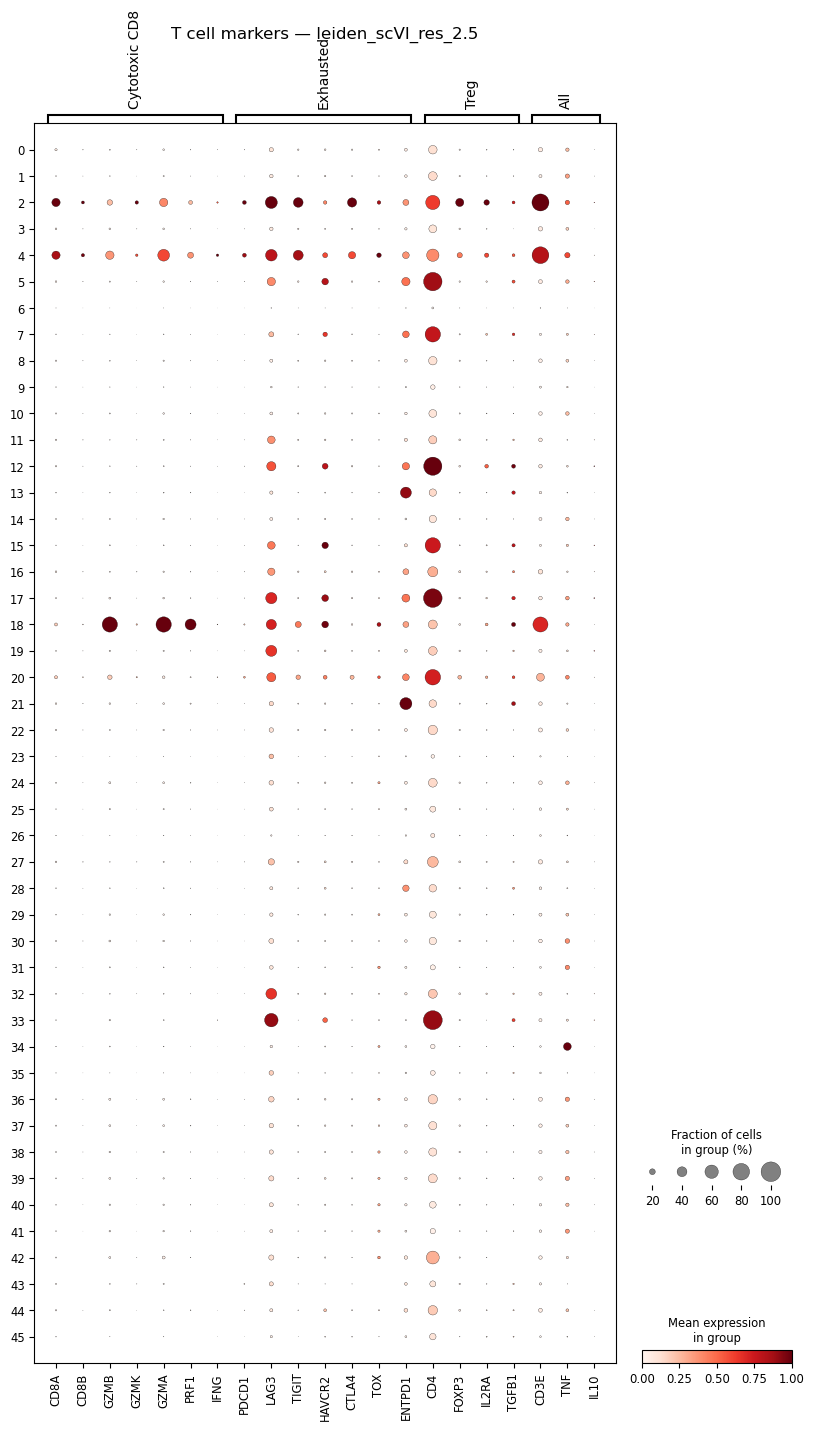


RESOLUTION: leiden_scVI_res_2


/global/home/users/fosterangus/.conda/envs/scvi/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:458: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
/global/home/users/fosterangus/.conda/envs/scvi/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:460: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
/global/home/users/fosterangus/.conda/envs/scvi/lib/python3.12/site-packages/scanpy/t


--- Top DE genes per cluster (log_norm) ---
Cluster 0: ['PVT1', 'OGT', 'ITGB4', 'AR', 'NPR1', 'BTN3A1', 'PTPRF', 'DHCR24', 'IRAK1', 'MSLN', 'KLHL14', 'DDR1', 'FOLR1', 'TBRG4', 'TAP2']
Cluster 1: ['CD3E', 'ITGAL', 'IL2RG', 'ACAP1', 'CXCR3', 'IL2RB', 'CD2', 'CD247', 'ZAP70', 'ITGB2', 'RASGRP1', 'SEMA4D', 'LAG3', 'GBP5', 'TNFRSF1B']
Cluster 2: ['EEF1G', 'DEPTOR', 'ADAMTS1', 'ITGB4', 'CFB', 'MSLN', 'DDR1', 'PTPRF', 'IMPDH2', 'CCT6A', 'AR', 'S100A1', 'NPR1', 'PABPC4', 'ATP5F1A']
Cluster 3: ['ITGB2', 'CYBB', 'CD4', 'SLCO2B1', 'CSF1R', 'GRN', 'SIGLEC1', 'CD14', 'STAB1', 'MAN2B1', 'CD68', 'MSR1', 'SLC7A7', 'MMP9', 'CTSH']
Cluster 4: ['STMN2', 'ARG1', 'CYP2A6', 'SLC2A2', 'PLG', 'C9', 'AHSG', 'C8B', 'AFM', 'TM4SF5', 'OPN1LW', 'GYPB', 'NR0B2', 'PAH', 'SERPIND1']
Cluster 5: ['SIGLEC1', 'CD14', 'GRN', 'STAB1', 'ITGB2', 'CD4', 'SLCO2B1', 'TYMP', 'CSF1R', 'MSR1', 'ITGAX', 'CYBB', 'CTSL', 'GAA', 'FCGR2A']
Cluster 6: ['DEPTOR', 'ITGB4', 'AR', 'NPR1', 'PVT1', 'OGT', 'PTPRF', 'EEF1G', 'DDR1', 'IRAK1', '

/tmp/ipykernel_1118701/436896345.py:49: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_scores = adata.obs.groupby(groupby_key)[score_cols].mean()
/tmp/ipykernel_1118701/436896345.py:51: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_scores['cell_count'] = adata.obs.groupby(groupby_key).size()



--- Marker set scores and cell counts per cluster (log_norm) ---
                   Cytotoxic_CD8_score  Exhausted_CD8_score  Treg_score  \
leiden_scVI_res_2                                                         
0                            -0.062442            -0.171016   -0.178627   
1                             0.642002             0.691754    0.792251   
2                            -0.056167            -0.142900   -0.150460   
3                            -0.054358            -0.031604    0.242660   
4                             0.000504            -0.004420    0.015469   
5                            -0.035993             0.002749    0.300232   
6                            -0.078669            -0.191704   -0.195342   
7                            -0.075188            -0.207147   -0.201435   
8                            -0.081656            -0.099952   -0.061430   
9                            -0.059454             0.035522    0.364428   
10                           -0.09

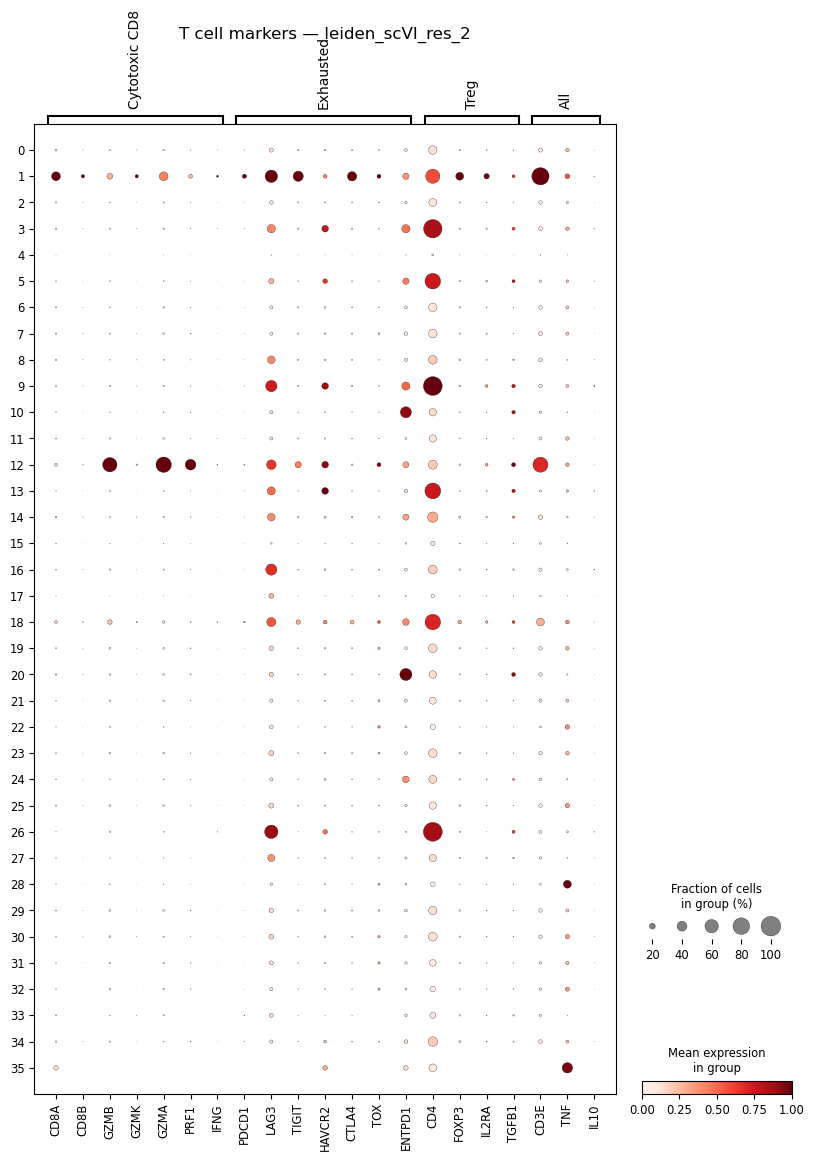


RESOLUTION: leiden_scVI_res_1.5


/global/home/users/fosterangus/.conda/envs/scvi/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:458: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
/global/home/users/fosterangus/.conda/envs/scvi/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:460: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
/global/home/users/fosterangus/.conda/envs/scvi/lib/python3.12/site-packages/scanpy/t


--- Top DE genes per cluster (log_norm) ---
Cluster 0: ['PVT1', 'OGT', 'ITGB4', 'AR', 'NPR1', 'BTN3A1', 'DHCR24', 'PTPRF', 'KLHL14', 'FOLR1', 'MSLN', 'IRAK1', 'DDR1', 'TBRG4', 'MLPH']
Cluster 1: ['CD3E', 'ITGAL', 'IL2RG', 'ACAP1', 'IL2RB', 'CXCR3', 'CD247', 'CD2', 'ZAP70', 'ITGB2', 'SEMA4D', 'RASGRP1', 'LAG3', 'GBP5', 'CD44']
Cluster 2: ['EEF1G', 'DEPTOR', 'ITGB4', 'ADAMTS1', 'CFB', 'DDR1', 'MSLN', 'PTPRF', 'IMPDH2', 'CCT6A', 'AR', 'S100A1', 'NPR1', 'PABPC4', 'ATP5F1A']
Cluster 3: ['ITGB2', 'CYBB', 'CD4', 'SLCO2B1', 'CSF1R', 'GRN', 'SIGLEC1', 'CD14', 'STAB1', 'MAN2B1', 'CD68', 'SLC7A7', 'MSR1', 'MMP9', 'CTSH']
Cluster 4: ['EEF1G', 'ZNF683', 'ID4', 'ICOSLG', 'BAD', 'SHFL', 'ANGPTL6', 'SFRP4', 'COMP', 'COL10A1', 'PRMT8', 'HTR4', 'CYP17A1', 'FGFBP2', 'GNB3']
Cluster 5: ['CD14', 'SIGLEC1', 'STAB1', 'CD4', 'GRN', 'SLCO2B1', 'CSF1R', 'ITGB2', 'CTSL', 'CYBB', 'TYMP', 'MSR1', 'GAA', 'CD163', 'CD68']
Cluster 6: ['DEPTOR', 'ITGB4', 'AR', 'NPR1', 'PVT1', 'OGT', 'PTPRF', 'DDR1', 'EEF1G', 'IRAK1',

/tmp/ipykernel_1118701/436896345.py:49: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_scores = adata.obs.groupby(groupby_key)[score_cols].mean()
/tmp/ipykernel_1118701/436896345.py:51: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_scores['cell_count'] = adata.obs.groupby(groupby_key).size()



--- Marker set scores and cell counts per cluster (log_norm) ---
                     Cytotoxic_CD8_score  Exhausted_CD8_score  Treg_score  \
leiden_scVI_res_1.5                                                         
0                              -0.066269            -0.174966   -0.183378   
1                               0.640060             0.687535    0.784936   
2                              -0.054647            -0.141492   -0.147367   
3                              -0.053869            -0.027020    0.252104   
4                              -0.002451            -0.017028    0.025716   
5                              -0.049964             0.020413    0.334468   
6                              -0.077465            -0.190017   -0.191043   
7                              -0.074845            -0.180464   -0.195844   
8                              -0.088507            -0.216628   -0.211893   
9                              -0.079695            -0.082710   -0.079777   
10        

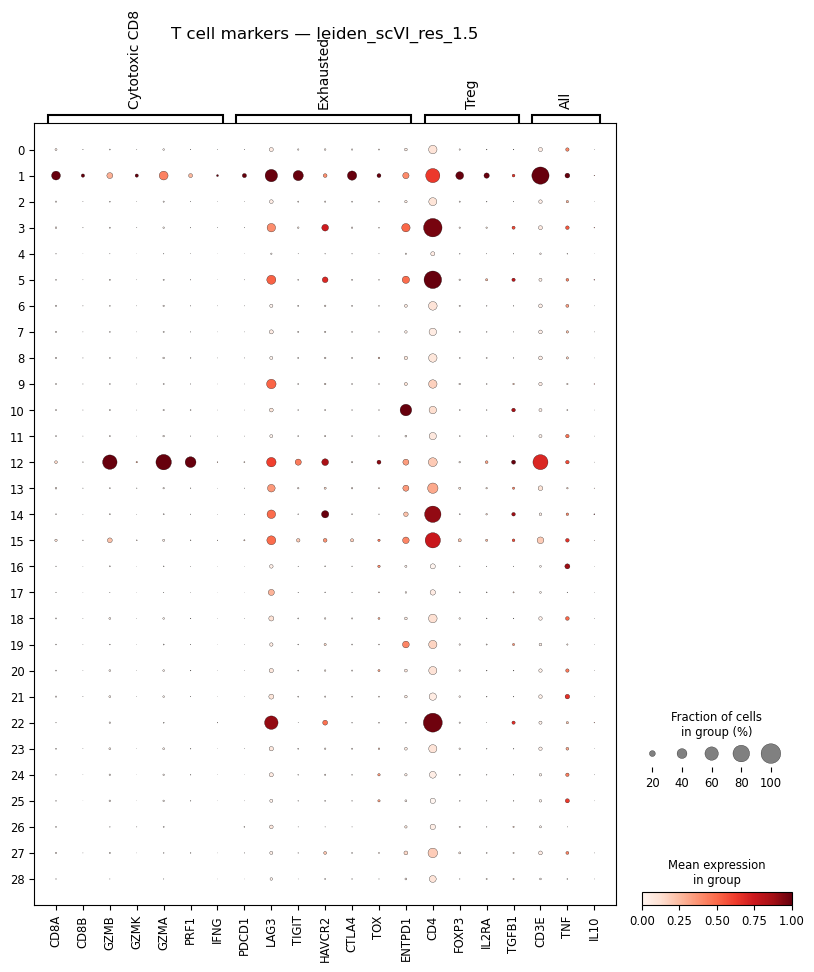


RESOLUTION: leiden_scVI_res_1


/global/home/users/fosterangus/.conda/envs/scvi/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:458: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
/global/home/users/fosterangus/.conda/envs/scvi/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:460: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
/global/home/users/fosterangus/.conda/envs/scvi/lib/python3.12/site-packages/scanpy/t


--- Top DE genes per cluster (log_norm) ---
Cluster 0: ['PVT1', 'OGT', 'FOLR1', 'DHCR24', 'GPT', 'NPR1', 'AR', 'MLPH', 'DDR1', 'IMPDH2', 'ITGB4', 'IRAK1', 'KLHL14', 'MCM7', 'MSLN']
Cluster 1: ['CD3E', 'IL2RB', 'IL2RG', 'CD247', 'ITGAL', 'ACAP1', 'SEMA4D', 'ZAP70', 'CXCR3', 'TNFRSF18', 'ADGRE5', 'CD7', 'GZMA', 'CD96', 'RASGRP1']
Cluster 2: ['ITGB4', 'EEF1G', 'DEPTOR', 'AR', 'PTPRF', 'DDR1', 'NPR1', 'PVT1', 'MSLN', 'ADAMTS1', 'IMPDH2', 'OGT', 'IRAK1', 'S100A1', 'ITPR3']
Cluster 3: ['ITGB2', 'CYBB', 'CD4', 'SLCO2B1', 'CSF1R', 'GRN', 'SIGLEC1', 'CD14', 'STAB1', 'MAN2B1', 'CD68', 'SLC7A7', 'MSR1', 'FCGR2A', 'CTSH']
Cluster 4: ['EEF1G', 'ZNF683', 'ID4', 'ICOSLG', 'SFRP4', 'BAD', 'SHFL', 'COMP', 'COL10A1', 'COL5A1', 'ANGPTL6', 'COL5A2', 'PRMT8', 'CYP17A1', 'HTR4']
Cluster 5: ['CD14', 'SIGLEC1', 'GRN', 'CD4', 'ITGB2', 'SLCO2B1', 'STAB1', 'CSF1R', 'CTSL', 'TYMP', 'CYBB', 'MSR1', 'CD68', 'GAA', 'ITGAX']
Cluster 6: ['OGT', 'IRAK1', 'ITGB4', 'PDIA3', 'PVT1', 'SORL1', 'EPCAM', 'L1CAM', 'DHCR24', '

/tmp/ipykernel_1118701/436896345.py:49: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_scores = adata.obs.groupby(groupby_key)[score_cols].mean()
/tmp/ipykernel_1118701/436896345.py:51: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_scores['cell_count'] = adata.obs.groupby(groupby_key).size()



--- Marker set scores and cell counts per cluster (log_norm) ---
                   Cytotoxic_CD8_score  Exhausted_CD8_score  Treg_score  \
leiden_scVI_res_1                                                         
0                            -0.069414            -0.177122   -0.187925   
1                             0.673711             0.596562    0.609574   
2                            -0.067270            -0.167879   -0.169421   
3                            -0.058835            -0.030789    0.252040   
4                            -0.006148            -0.021029    0.020091   
5                            -0.049994             0.020657    0.327840   
6                            -0.065175            -0.174528   -0.192688   
7                            -0.082699            -0.080610   -0.078363   
8                            -0.085478            -0.050762    0.064919   
9                            -0.049239            -0.050444    0.040338   
10                           -0.04

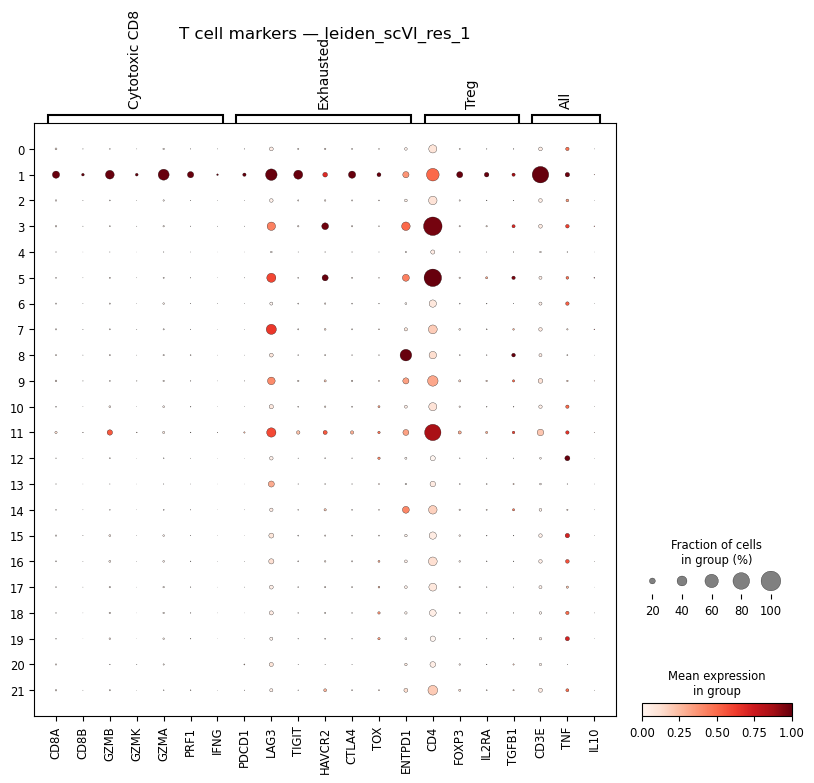


RESOLUTION: leiden_scVI_res_0.75

--- Top DE genes per cluster (log_norm) ---
Cluster 0: ['PVT1', 'OGT', 'FOLR1', 'GPT', 'DHCR24', 'NPR1', 'AR', 'MLPH', 'DDR1', 'IMPDH2', 'IRAK1', 'ITGB4', 'KLHL14', 'MCM7', 'MSLN']
Cluster 1: ['CD3E', 'IL2RB', 'IL2RG', 'CD247', 'ITGAL', 'ACAP1', 'SEMA4D', 'ZAP70', 'CXCR3', 'TNFRSF18', 'ADGRE5', 'CD7', 'GZMA', 'CD96', 'RASGRP1']
Cluster 2: ['EEF1G', 'ITGB4', 'DEPTOR', 'AR', 'PTPRF', 'DDR1', 'NPR1', 'PVT1', 'MSLN', 'ADAMTS1', 'IMPDH2', 'IRAK1', 'OGT', 'S100A1', 'ITPR3']
Cluster 3: ['SIGLEC1', 'CD14', 'ITGB2', 'GRN', 'CD4', 'SLCO2B1', 'CSF1R', 'STAB1', 'CTSL', 'CYBB', 'TYMP', 'MSR1', 'CD68', 'ITGAX', 'GAA']
Cluster 4: ['EEF1G', 'ZNF683', 'SFRP4', 'ID4', 'ICOSLG', 'COL10A1', 'COMP', 'BAD', 'COL5A1', 'SHFL', 'COL5A2', 'ANGPTL6', 'THBS1', 'AEBP1', 'PRMT8']
Cluster 5: ['OGT', 'ITGB4', 'IRAK1', 'PDIA3', 'PVT1', 'SORL1', 'L1CAM', 'EPCAM', 'DHCR24', 'BCL11A', 'COL18A1', 'PTPRF', 'AR', 'IMPDH2', 'TNFRSF14']
Cluster 6: ['COL5A1', 'LTBP2', 'MRC2', 'COL5A2', 'SFRP4

/tmp/ipykernel_1118701/436896345.py:49: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_scores = adata.obs.groupby(groupby_key)[score_cols].mean()
/tmp/ipykernel_1118701/436896345.py:51: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_scores['cell_count'] = adata.obs.groupby(groupby_key).size()



--- Marker set scores and cell counts per cluster (log_norm) ---
                      Cytotoxic_CD8_score  Exhausted_CD8_score  Treg_score  \
leiden_scVI_res_0.75                                                         
0                               -0.071856            -0.179601   -0.189096   
1                                0.673918             0.596972    0.610353   
2                               -0.066425            -0.164979   -0.161206   
3                               -0.051218             0.010804    0.313367   
4                               -0.008039            -0.023548    0.013477   
5                               -0.065726            -0.175241   -0.192363   
6                               -0.083285            -0.079084   -0.074920   
7                               -0.085367            -0.050090    0.066394   
8                               -0.050017            -0.052086    0.036454   
9                               -0.049821            -0.140156   -0.152559  

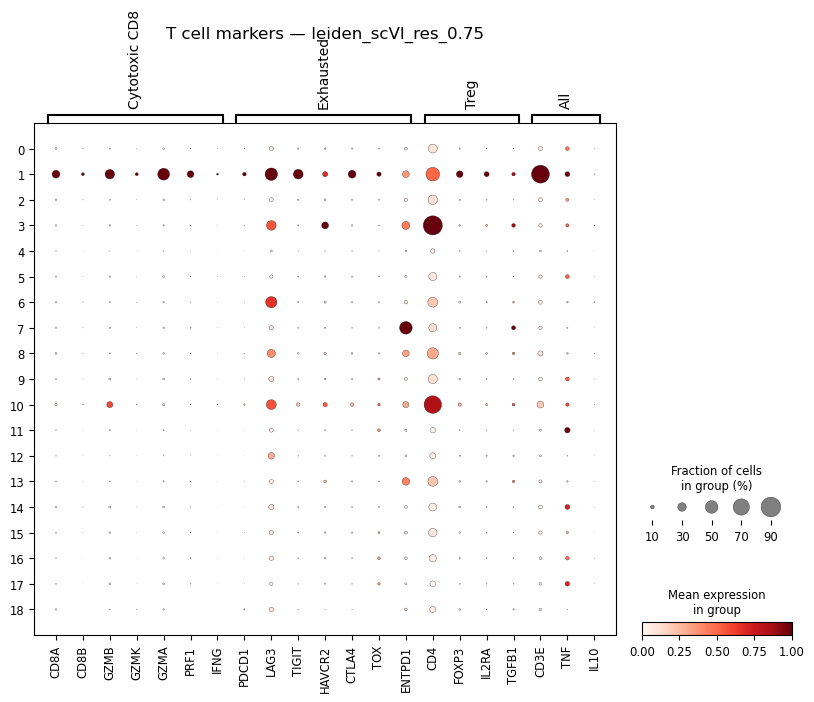


RESOLUTION: leiden_scVI_res_0.65

--- Top DE genes per cluster (log_norm) ---
Cluster 0: ['PVT1', 'OGT', 'FOLR1', 'GPT', 'DHCR24', 'NPR1', 'AR', 'MLPH', 'DDR1', 'IMPDH2', 'ITGB4', 'IRAK1', 'KLHL14', 'MCM7', 'MSLN']
Cluster 1: ['CD3E', 'IL2RB', 'IL2RG', 'CD247', 'ITGAL', 'ACAP1', 'SEMA4D', 'ZAP70', 'CXCR3', 'TNFRSF18', 'ADGRE5', 'CD7', 'GZMA', 'CD96', 'RASGRP1']
Cluster 2: ['EEF1G', 'ITGB4', 'DEPTOR', 'AR', 'PTPRF', 'DDR1', 'NPR1', 'PVT1', 'MSLN', 'ADAMTS1', 'IMPDH2', 'IRAK1', 'OGT', 'S100A1', 'ITPR3']
Cluster 3: ['SIGLEC1', 'CD14', 'ITGB2', 'GRN', 'CD4', 'SLCO2B1', 'CSF1R', 'STAB1', 'CYBB', 'CTSL', 'TYMP', 'MSR1', 'CD68', 'ITGAX', 'GAA']
Cluster 4: ['EEF1G', 'ZNF683', 'ID4', 'ICOSLG', 'BAD', 'SHFL', 'ANGPTL6', 'COMP', 'HTR4', 'PRMT8', 'CYP17A1', 'COL10A1', 'FGFBP2', 'GNB3', 'SFRP4']
Cluster 5: ['OGT', 'ITGB4', 'IRAK1', 'PDIA3', 'PVT1', 'SORL1', 'L1CAM', 'EPCAM', 'DHCR24', 'BCL11A', 'COL18A1', 'PTPRF', 'AR', 'IMPDH2', 'TNFRSF14']
Cluster 6: ['THBS1', 'AEBP1', 'CDH11', 'PDGFRA', 'MRC2',

/tmp/ipykernel_1118701/436896345.py:49: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_scores = adata.obs.groupby(groupby_key)[score_cols].mean()
/tmp/ipykernel_1118701/436896345.py:51: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_scores['cell_count'] = adata.obs.groupby(groupby_key).size()



--- Marker set scores and cell counts per cluster (log_norm) ---
                      Cytotoxic_CD8_score  Exhausted_CD8_score  Treg_score  \
leiden_scVI_res_0.65                                                         
0                               -0.071673            -0.179808   -0.189752   
1                                0.674451             0.597536    0.610832   
2                               -0.066071            -0.164849   -0.161355   
3                               -0.052644             0.011161    0.317490   
4                               -0.002139            -0.016102    0.032199   
5                               -0.065707            -0.175389   -0.192928   
6                               -0.090922            -0.102264   -0.097992   
7                               -0.086135            -0.050801    0.065767   
8                               -0.050060            -0.052373    0.036555   
9                               -0.049935            -0.139759   -0.152119  

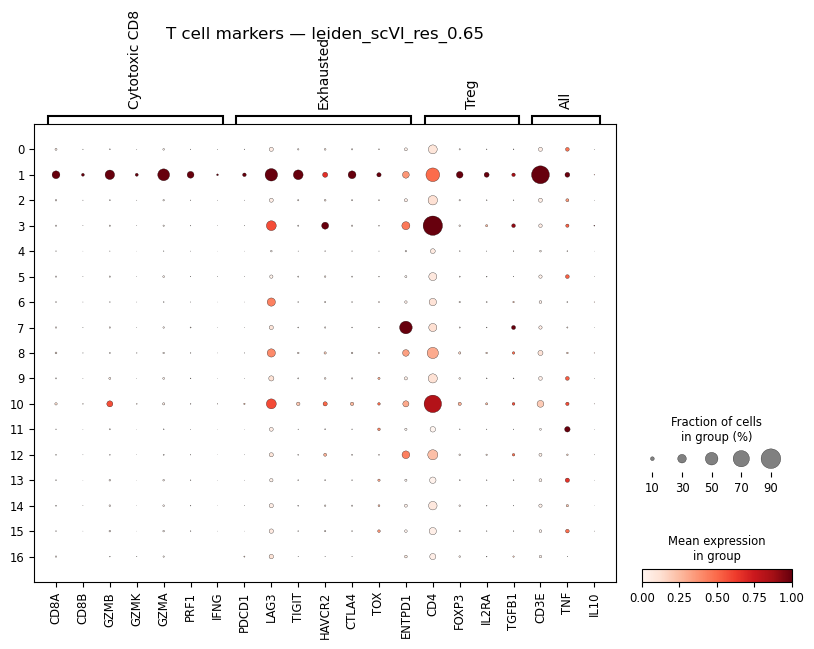


RESOLUTION: leiden_scVI_res_0.5

--- Top DE genes per cluster (log_norm) ---
Cluster 0: ['ITGB4', 'EEF1G', 'DEPTOR', 'AR', 'PTPRF', 'DDR1', 'NPR1', 'PVT1', 'MSLN', 'ADAMTS1', 'IMPDH2', 'OGT', 'IRAK1', 'S100A1', 'DHCR24']
Cluster 1: ['CD3E', 'IL2RB', 'IL2RG', 'CD247', 'ITGAL', 'ACAP1', 'SEMA4D', 'ZAP70', 'CXCR3', 'TNFRSF18', 'ADGRE5', 'CD7', 'GZMA', 'SELPLG', 'CD96']
Cluster 2: ['SIGLEC1', 'CD14', 'ITGB2', 'GRN', 'CD4', 'SLCO2B1', 'CSF1R', 'STAB1', 'CTSL', 'CYBB', 'TYMP', 'MSR1', 'CD68', 'ITGAX', 'GAA']
Cluster 3: ['EEF1G', 'ZNF683', 'SFRP4', 'ID4', 'ICOSLG', 'COL10A1', 'COL5A1', 'COMP', 'BAD', 'SHFL', 'COL5A2', 'THBS1', 'AEBP1', 'ANGPTL6', 'PRMT8']
Cluster 4: ['COL5A1', 'LTBP2', 'MRC2', 'COL5A2', 'SFRP4', 'AEBP1', 'THBS2', 'THBS1', 'NBL1', 'PTK7', 'CTHRC1', 'CDH11', 'MMP14', 'IGFBP2', 'COMP']
Cluster 5: ['COL4A1', 'MCAM', 'COL4A2', 'EPAS1', 'APP', 'CD34', 'SHANK3', 'ENG', 'COL18A1', 'NOTCH4', 'TIE1', 'PECAM1', 'MYH9', 'INSR', 'CDH5']
Cluster 6: ['MZB1', 'XBP1', 'DERL3', 'TENT5C', 'CD7

/tmp/ipykernel_1118701/436896345.py:49: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_scores = adata.obs.groupby(groupby_key)[score_cols].mean()
/tmp/ipykernel_1118701/436896345.py:51: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_scores['cell_count'] = adata.obs.groupby(groupby_key).size()



--- Marker set scores and cell counts per cluster (log_norm) ---
                     Cytotoxic_CD8_score  Exhausted_CD8_score  Treg_score  \
leiden_scVI_res_0.5                                                         
0                              -0.065667            -0.163856   -0.158062   
1                               0.658207             0.584321    0.604610   
2                              -0.051120             0.013030    0.316446   
3                              -0.008917            -0.023815    0.013095   
4                              -0.084912            -0.080838   -0.073990   
5                              -0.086561            -0.050744    0.066222   
6                              -0.051427            -0.053194    0.036136   
7                              -0.050156            -0.140217   -0.152499   
8                              -0.103488            -0.123655   -0.123904   
9                              -0.065779            -0.175530   -0.192347   
10        

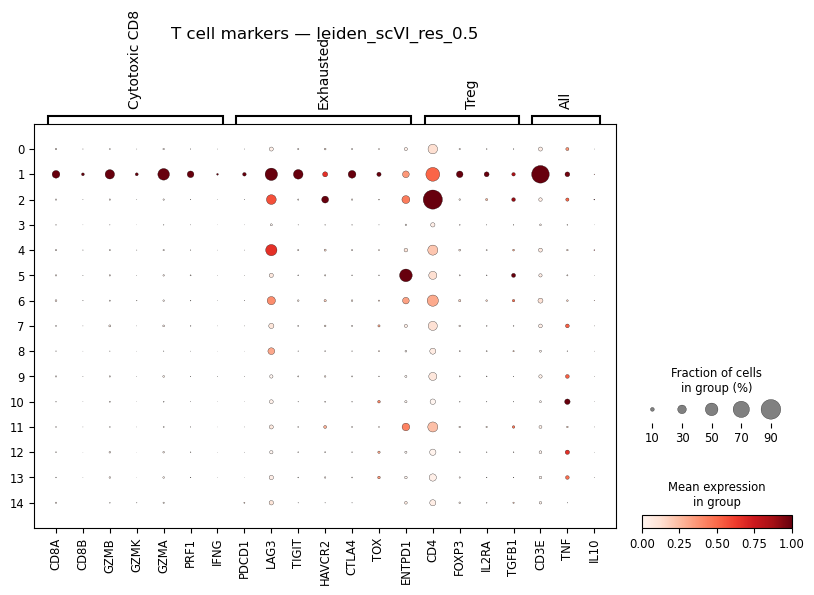

In [ ]:
marker_sets = {
    'Cytotoxic_CD8': ['CD8A', 'CD8B', 'CD3D', 'CD3E', 'GZMB', 'GZMK', 'GZMA', 'PRF1', 'IFNG', 'TNF'],
    'Exhausted_CD8': ['CD8A', 'CD8B', 'CD3D', 'CD3E', 'GZMB', 'GZMK', 'PDCD1', 'LAG3', 'TIGIT', 'HAVCR2', 'CTLA4', 'TOX', 'ENTPD1'],
    'Treg': ['CD4', 'CD3D', 'CD3E', 'FOXP3', 'IL2RA', 'CTLA4', 'IL10', 'TGFB1', 'ENTPD1'],
}

marker_genes_dotplot = {
    'Cytotoxic CD8': ['CD8A', 'CD8B', 'GZMB', 'GZMK', 'GZMA', 'PRF1', 'IFNG'],
    'Exhausted': ['PDCD1', 'LAG3', 'TIGIT', 'HAVCR2', 'CTLA4', 'TOX', 'ENTPD1'],
    'Treg': ['CD4', 'FOXP3', 'IL2RA', 'TGFB1'],
    'All': ['CD3D', 'CD3E', 'TNF', 'IL10'],
}


def annotate_clusters(adata, groupby_key, n_top_genes=15, de_genes_dict=None):
    print(f"\n{'='*60}")
    print(f"RESOLUTION: {groupby_key}")
    print(f"{'='*60}")
    
    # --- Approach 1: top DE genes per cluster (on log_norm) ---
    sc.tl.rank_genes_groups(
        adata,
        groupby=groupby_key,
        method='wilcoxon',
        layer='log_norm',
        use_raw=False
    )
    result = adata.uns['rank_genes_groups']
    groups = result['names'].dtype.names
    
    # Initialize dictionary for this resolution if provided
    if de_genes_dict is not None:
        de_genes_dict[groupby_key] = {}
    
    print("\n--- Top DE genes per cluster (log_norm) ---")
    for group in groups:
        top_genes = result['names'][group][:n_top_genes]
        print(f"Cluster {group}: {list(top_genes)}")
        # Save DE genes to the dictionary
        if de_genes_dict is not None:
            de_genes_dict[groupby_key][group] = list(top_genes)
    
    # --- Approach 2: marker set scores per cluster (on log_norm) ---
    for name, genes in marker_sets.items():
        genes_present = [g for g in genes if g in adata.var_names]
        sc.tl.score_genes(
            adata,
            gene_list=genes_present,
            score_name=f'{name}_score',
            layer='log_norm'
        )
    
    score_cols = [f'{name}_score' for name in marker_sets.keys()]

    # 1. Calculate the mean scores per cluster
    cluster_scores = adata.obs.groupby(groupby_key)[score_cols].mean()
    # 2. Calculate the cell count per cluster and add it as a new column
    cluster_scores['cell_count'] = adata.obs.groupby(groupby_key).size()
    print("\n--- Marker set scores and cell counts per cluster (log_norm) ---")
    print(cluster_scores)
    
    # --- Approach 3: dot plot (on log_norm) ---
    marker_genes_filt = {
        group: [g for g in genes if g in adata.var_names]
        for group, genes in marker_genes_dotplot.items()
    }
    sc.pl.dotplot(
        adata,
        var_names=marker_genes_filt,
        groupby=groupby_key,
        layer='log_norm',
        standard_scale='var',
        title=f'T cell markers — {groupby_key}'
    )
    
    return cluster_scores

# Initialize the dictionary and run the loop
de_genes_dict = {}
all_scores = {}
for res_key in res_labels:
    all_scores[res_key] = annotate_clusters(adata, res_key, de_genes_dict=de_genes_dict)

In [ ]:
all_scores[res_label(0.75)]

,Cytotoxic_CD8_score,Exhausted_CD8_score,Treg_score,cell_count
leiden_scVI_res_0.75,,,,
0,-0.071856,-0.179601,-0.189096,14838
1,0.673918,0.596972,0.610353,85462
2,-0.066425,-0.164979,-0.161206,187853
3,-0.051218,0.010804,0.313367,132130
4,-0.008039,-0.023548,0.013477,91647
5,-0.065726,-0.175241,-0.192363,71215
6,-0.083285,-0.079084,-0.074920,59607
7,-0.085367,-0.050090,0.066394,40413
8,-0.050017,-0.052086,0.036454,25505


/tmp/ipykernel_1118701/1014824437.py:8: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, spot_size=5, show=False, title=DATASET_NAME, color='t_cell');


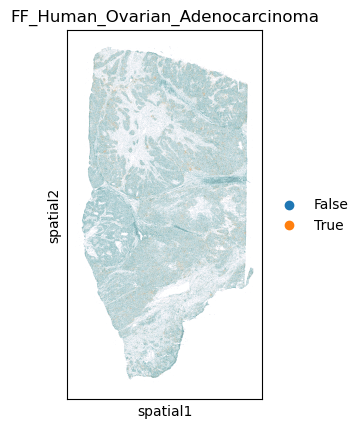

In [ ]:
res = 0.75
cd8 = ['1'] #CD8
cd4 = ['19'] #CD4
t_cell_clusts = list(set(cd8 + cd4))
adata.obs['cd8'] = adata.obs[res_label(res)].isin(cd8) 
adata.obs['cd4'] = adata.obs[res_label(res)].isin(cd4)
adata.obs['t_cell'] = adata.obs[res_label(res)].isin(t_cell_clusts) 
sc.pl.spatial(adata, spot_size=5, show=False, title=DATASET_NAME, color='t_cell');

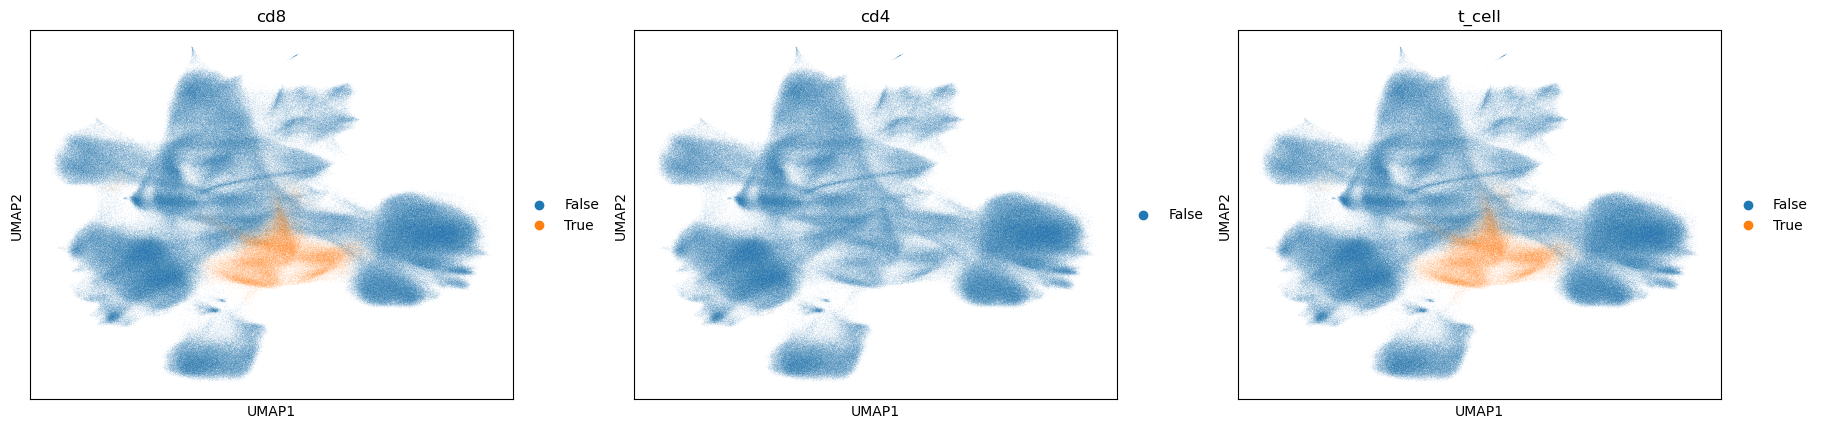

In [ ]:
sc.pl.umap(adata, color=['cd8', 'cd4', 't_cell'])

In [ ]:
print(f'Not t cell: {sum(~adata.obs['t_cell'])}')
print(f't cell: {sum(adata.obs['t_cell'])}')
print(f'cd8: {sum(adata.obs['cd8'])}')
print(f'cd4: {sum(adata.obs['cd4'])}')

Not t cell: 1072197
t cell: 85462
cd8: 85462
cd4: 0


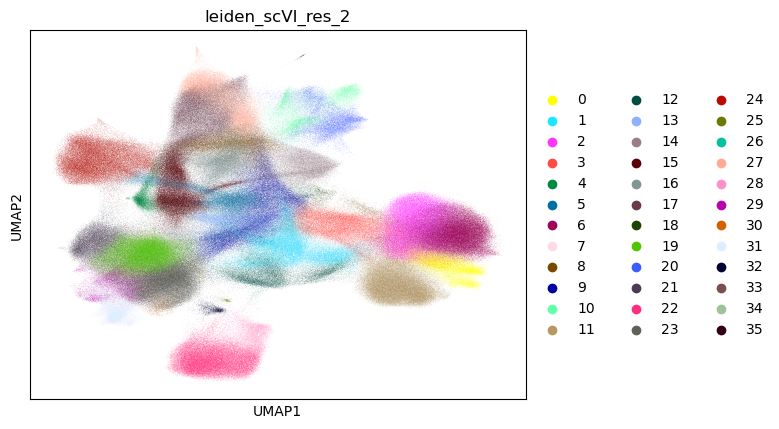

In [ ]:
sc.pl.umap(adata, color=[res_label(2)])

In [ ]:
def sub_res_label(res, clusters):
    """Order of clusters does not matter"""
    return f'sub_cluster_{"-".join(sorted(clusters))}_res_{res}'

def subcluster(adata, clusters, sub_res, clusters_res_label, de_genes_dict=None):
    print(f'Starting Sub Resolutions {sub_res}')
    new_col_name = sub_res_label(sub_res, clusters)

    # 2. Filter the adata to include only the targeted clusters
    subset_mask = adata.obs[clusters_res_label].isin(clusters)
    adata_sub = adata[subset_mask].copy()

    if new_col_name in adata.obs:
        print(f'{new_col_name} already in adata, skipping')
        # Re-load the existing labels into the subset for DE calculation
        adata_sub.obs[new_col_name] = adata.obs.loc[subset_mask, new_col_name].values
    else:
        # 3. Run the Leiden clustering on the subset
        sc.tl.leiden(adata_sub, resolution=sub_res, key_added=new_col_name, flavor='igraph')
        
        # 4. Initialize the new column in the original adata with "other"
        adata.obs[new_col_name] = "other"
        
        # 5. Map the subset's new cluster results back to the original adata
        adata.obs.loc[subset_mask, new_col_name] = adata_sub.obs[new_col_name].astype(str)
        adata.obs[new_col_name] = adata.obs[new_col_name].astype('category')
    
    # Dot plot base setup
    marker_genes_filt = {
        group: [g for g in genes if g in adata.var_names]
        for group, genes in marker_genes_dotplot.items()
    }
    
    # Compute top DE genes for each new subcluster
    sc.tl.rank_genes_groups(
        adata_sub,
        groupby=new_col_name,
        method='wilcoxon',
        layer='log_norm',
        use_raw=False
    )
    result = adata_sub.uns['rank_genes_groups']
    sub_groups = result['names'].dtype.names
    
    # Add top 10 DE genes per subcluster to the dotplot
    for group in sub_groups:
        top_sub_genes = result['names'][group][:10]
        marker_genes_filt[f'Subcluster {group} Top DE'] = [g for g in top_sub_genes if g in adata.var_names]

    sc.pl.dotplot(
        adata,
        var_names=marker_genes_filt,
        groupby=new_col_name,
        layer='log_norm',
        standard_scale='var',
        title=f'T cell markers & Subcluster DE — {new_col_name}'
    )

    print(f"\nSub-cluster sizes for {new_col_name}:")
    print(adata.obs[new_col_name].value_counts())
    
    return adata
    return adata

In [ ]:
sub_resolutions = [1, 0.75, 0.5, 0.37, 0.25, 0.15, 0.1, 0.05]

starting cd4
Starting Sub Resolutions {sub_res}


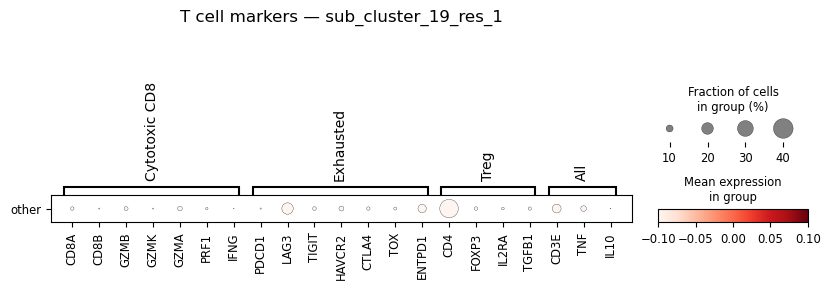


Sub-cluster sizes for sub_cluster_19_res_1:
sub_cluster_19_res_1
other    1157659
Name: count, dtype: int64
Starting Sub Resolutions {sub_res}


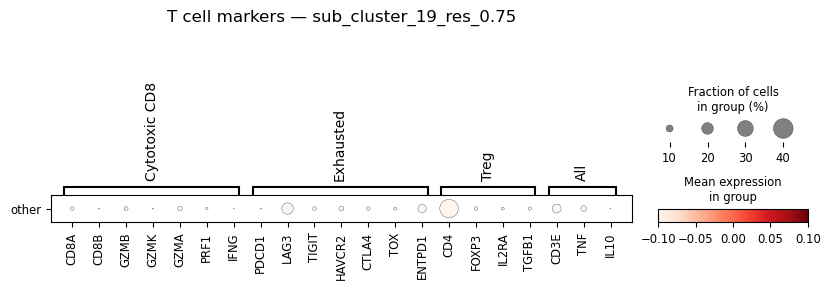


Sub-cluster sizes for sub_cluster_19_res_0.75:
sub_cluster_19_res_0.75
other    1157659
Name: count, dtype: int64
Starting Sub Resolutions {sub_res}


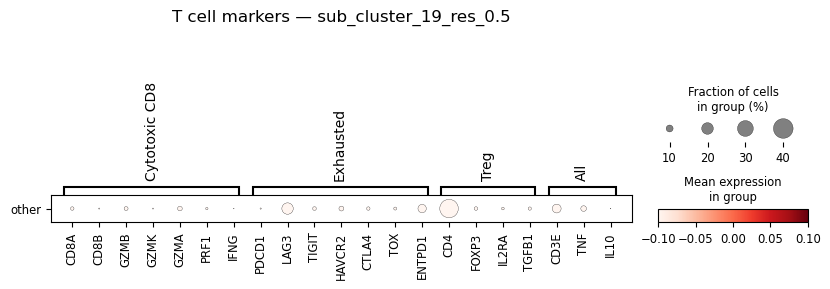


Sub-cluster sizes for sub_cluster_19_res_0.5:
sub_cluster_19_res_0.5
other    1157659
Name: count, dtype: int64
Starting Sub Resolutions {sub_res}


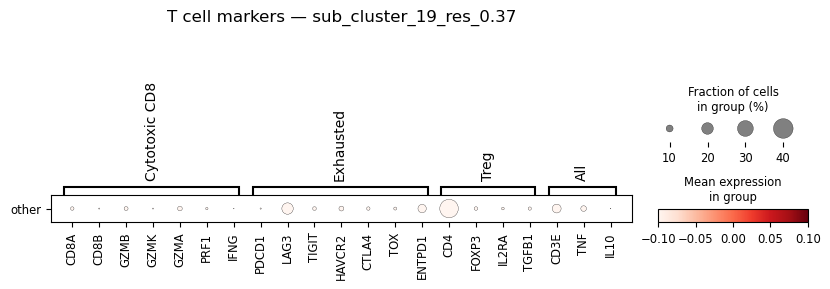


Sub-cluster sizes for sub_cluster_19_res_0.37:
sub_cluster_19_res_0.37
other    1157659
Name: count, dtype: int64
Starting Sub Resolutions {sub_res}


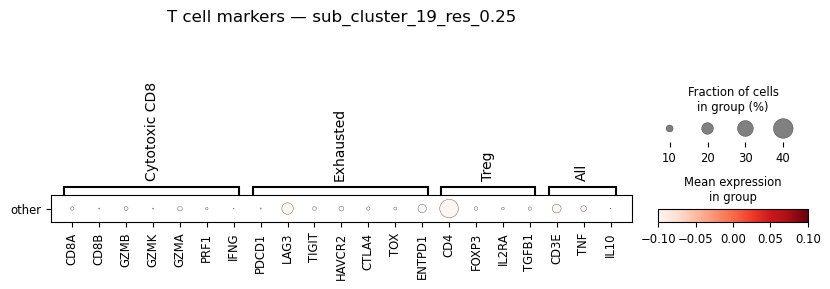


Sub-cluster sizes for sub_cluster_19_res_0.25:
sub_cluster_19_res_0.25
other    1157659
Name: count, dtype: int64
Starting Sub Resolutions {sub_res}


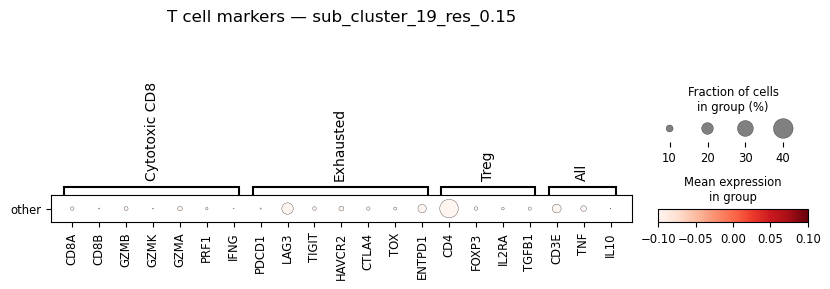


Sub-cluster sizes for sub_cluster_19_res_0.15:
sub_cluster_19_res_0.15
other    1157659
Name: count, dtype: int64
Starting Sub Resolutions {sub_res}


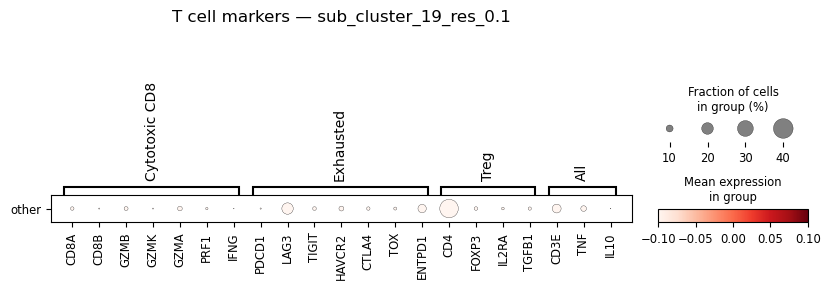


Sub-cluster sizes for sub_cluster_19_res_0.1:
sub_cluster_19_res_0.1
other    1157659
Name: count, dtype: int64
Starting Sub Resolutions {sub_res}


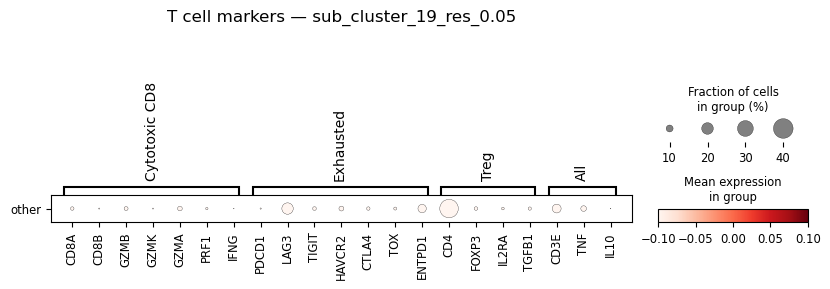


Sub-cluster sizes for sub_cluster_19_res_0.05:
sub_cluster_19_res_0.05
other    1157659
Name: count, dtype: int64


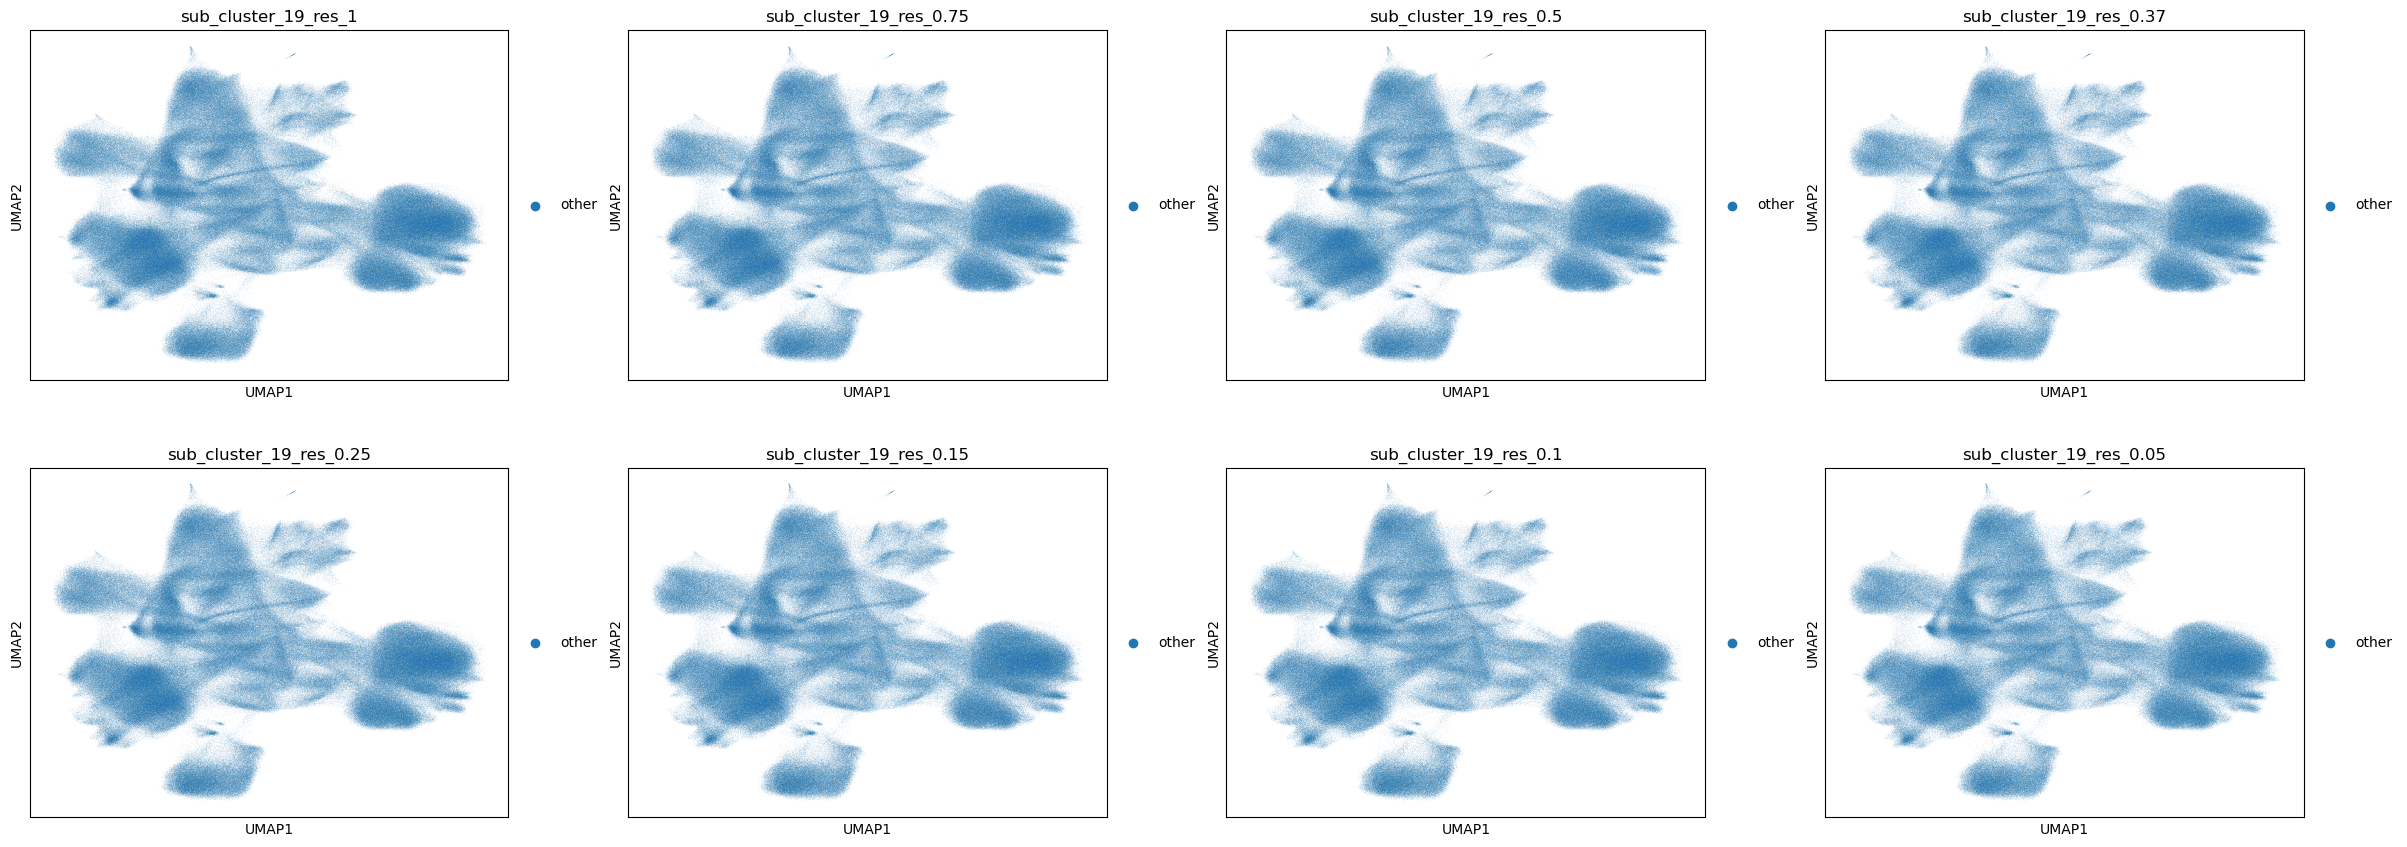

In [ ]:
print('starting cd4')
for sub_res in sub_resolutions:
    subcluster(adata, cd4, sub_res, clusters_res_label=res_label(res), de_genes_dict=de_genes_dict)
sc.pl.umap(adata, color=[sub_res_label(sub_res, cd4) for sub_res in sub_resolutions])

starting cd8
Starting Sub Resolutions {sub_res}


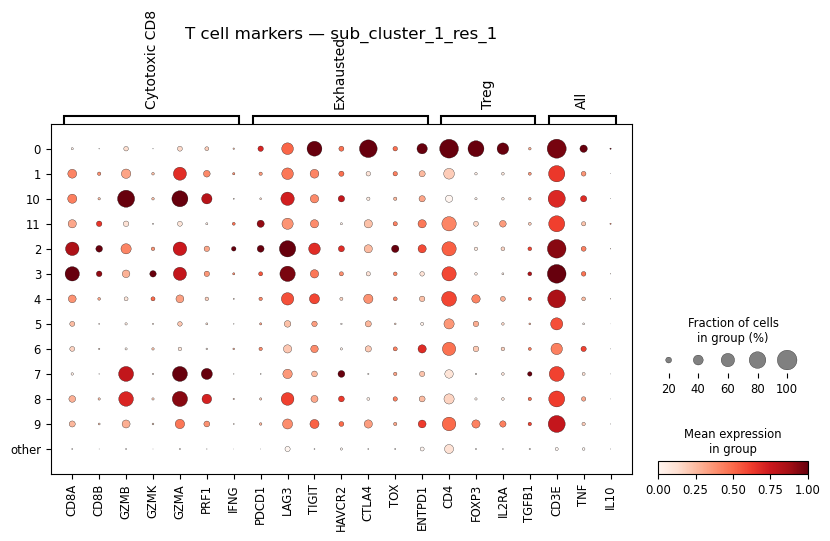


Sub-cluster sizes for sub_cluster_1_res_1:
sub_cluster_1_res_1
other    1072197
1          16994
0          11359
8          11359
4          10459
7           9626
5           9361
3           8651
9           3720
2           2104
6           1299
10           492
11            38
Name: count, dtype: int64
Starting Sub Resolutions {sub_res}


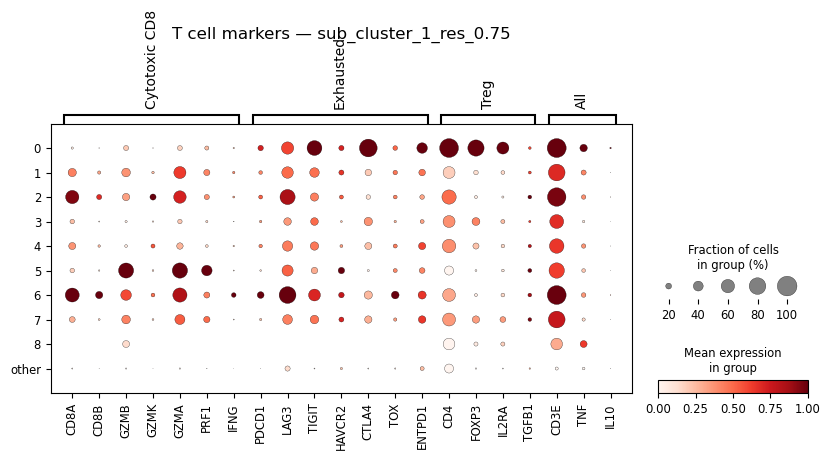


Sub-cluster sizes for sub_cluster_1_res_0.75:
sub_cluster_1_res_0.75
other    1072197
1          20417
5          19856
2          14302
3          13823
0           9551
7           3994
4           2185
6           1326
8              8
Name: count, dtype: int64
Starting Sub Resolutions {sub_res}


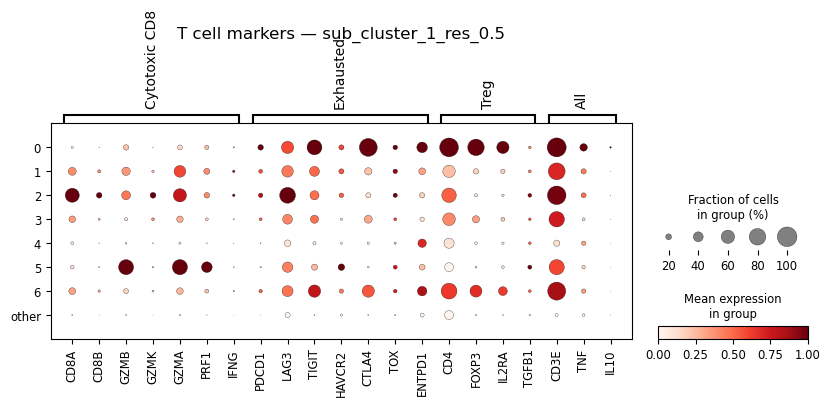


Sub-cluster sizes for sub_cluster_1_res_0.5:
sub_cluster_1_res_0.5
other    1072197
1          21953
3          20828
5          20340
2          12419
0           7359
6           1792
4            771
Name: count, dtype: int64
Starting Sub Resolutions {sub_res}


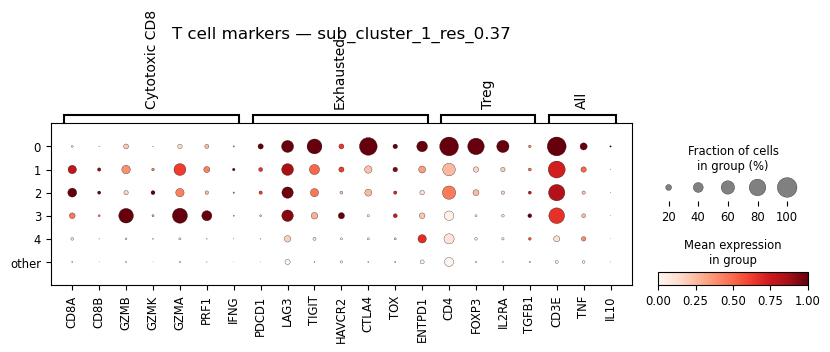


Sub-cluster sizes for sub_cluster_1_res_0.37:
sub_cluster_1_res_0.37
other    1072197
2          28664
3          24179
1          23070
0           8786
4            763
Name: count, dtype: int64
Starting Sub Resolutions {sub_res}


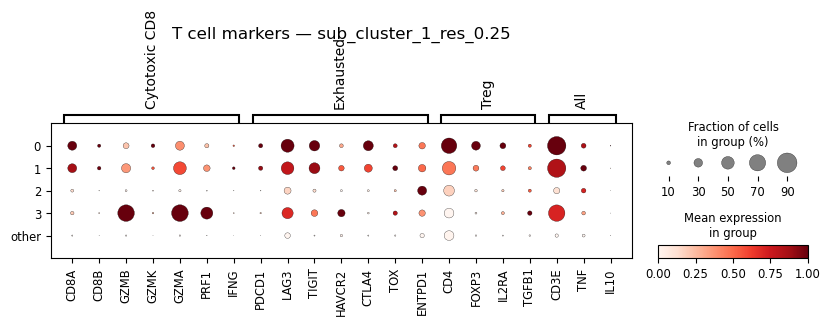


Sub-cluster sizes for sub_cluster_1_res_0.25:
sub_cluster_1_res_0.25
other    1072197
0          42805
1          22544
3          19393
2            720
Name: count, dtype: int64
Starting Sub Resolutions {sub_res}


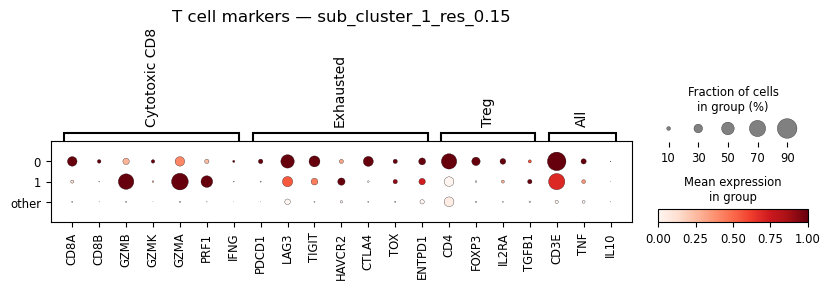


Sub-cluster sizes for sub_cluster_1_res_0.15:
sub_cluster_1_res_0.15
other    1072197
0          59486
1          25976
Name: count, dtype: int64
Starting Sub Resolutions {sub_res}


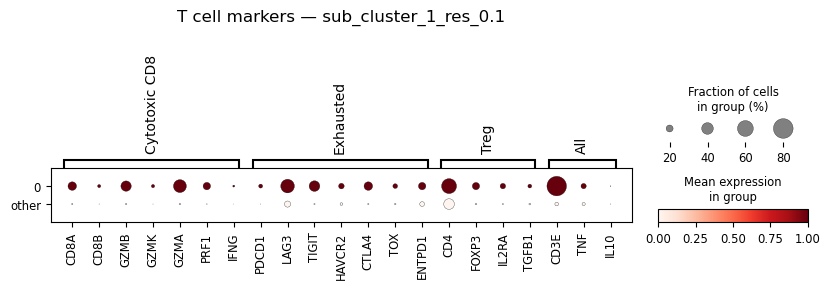


Sub-cluster sizes for sub_cluster_1_res_0.1:
sub_cluster_1_res_0.1
other    1072197
0          85462
Name: count, dtype: int64
Starting Sub Resolutions {sub_res}


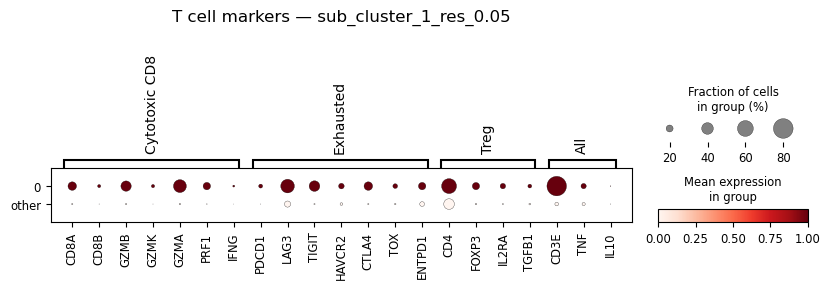


Sub-cluster sizes for sub_cluster_1_res_0.05:
sub_cluster_1_res_0.05
other    1072197
0          85462
Name: count, dtype: int64


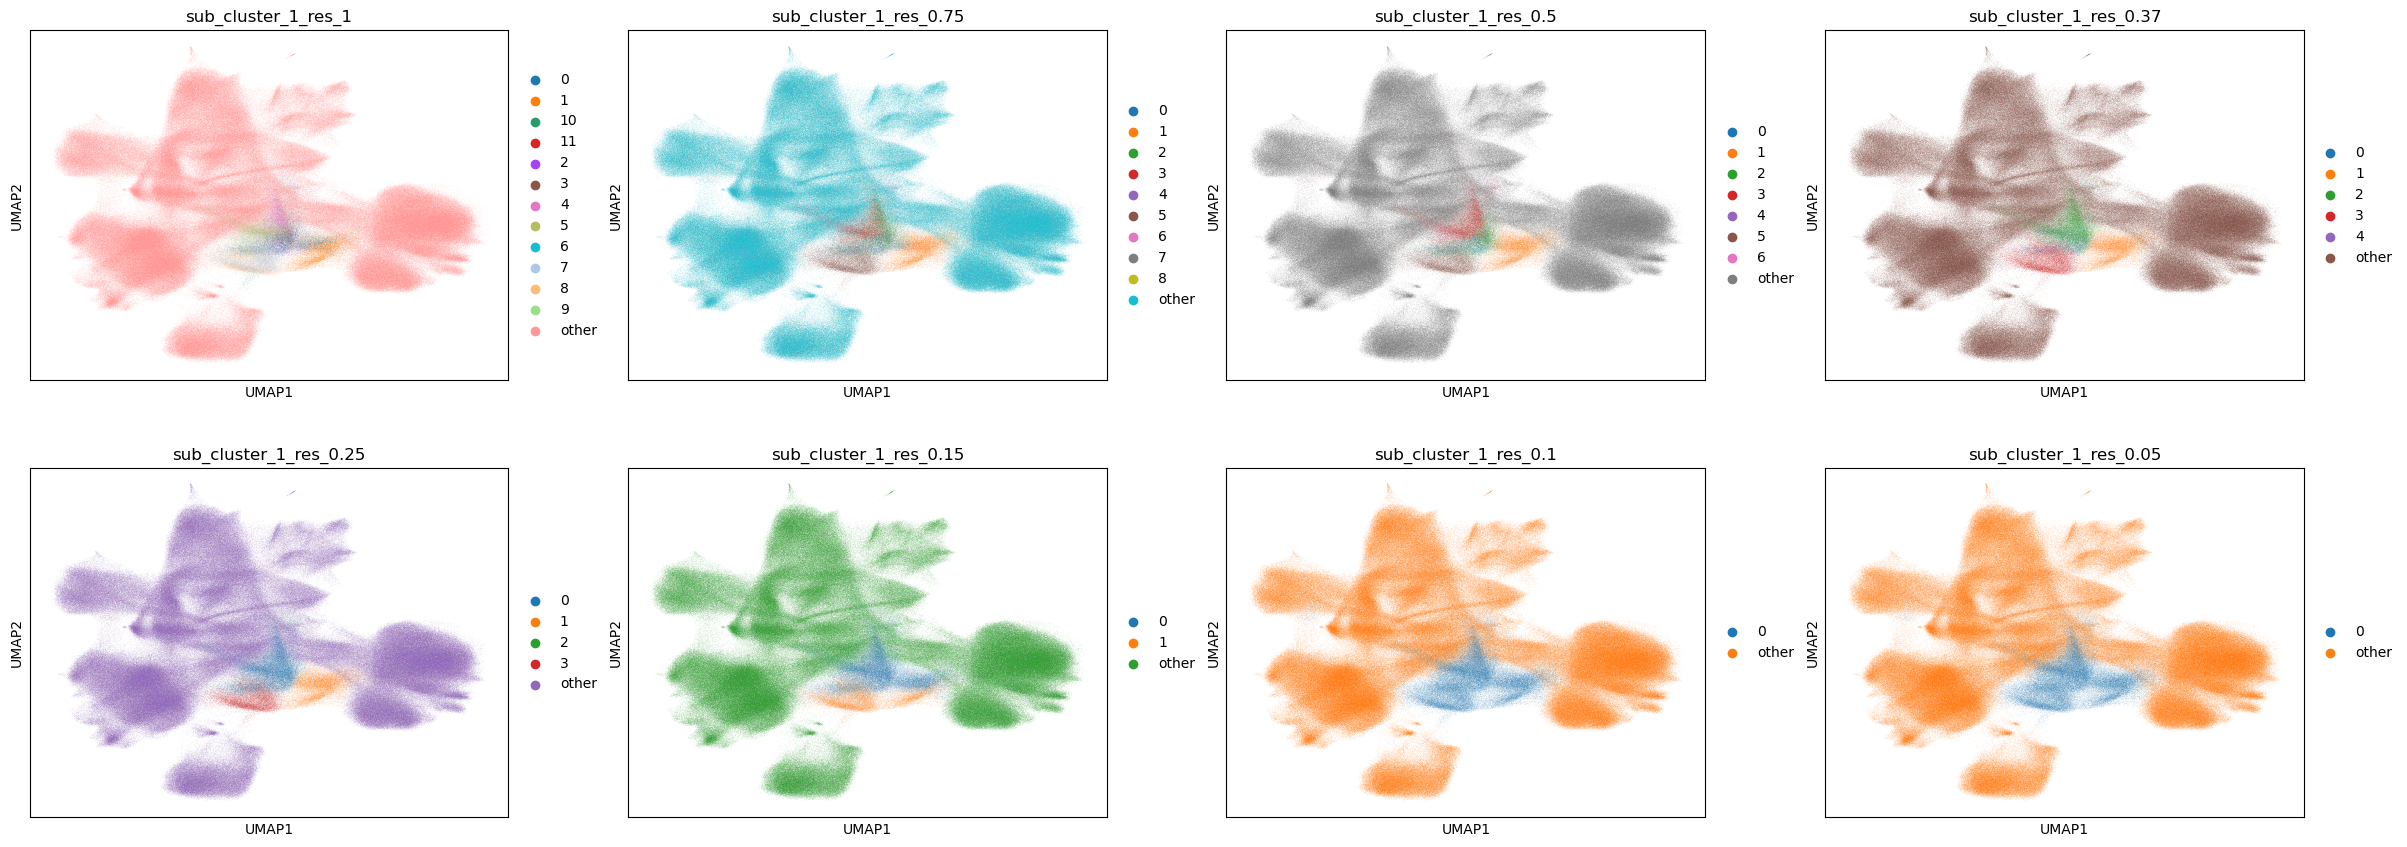

In [ ]:
print('starting cd8')
for sub_res in sub_resolutions:
    subcluster(adata, cd8, sub_res, clusters_res_label=res_label(res), de_genes_dict=de_genes_dict)
sc.pl.umap(adata, color=[sub_res_label(sub_res, cd8) for sub_res in sub_resolutions])

In [ ]:
# Time to assign

# Tier1
adata.obs['Tier1'] = 'other'
adata.obs.loc[adata.obs['t_cell'], 'Tier1'] = 'T Cell'
adata.obs['Tier1'] = adata.obs['Tier1'].astype('category')

# Tier2
conditions = [
    adata.obs[res_label(res)].isin(cd8),
    adata.obs[res_label(res)].isin(cd4)
]
choices = ['CD8 T Cell', 'CD4 T Cell']
# 2. Use np.select to assign the labels, defaulting to 'other'
adata.obs['Tier2'] = np.select(conditions, choices, default='other')
# 3. Convert to category for optimal memory and Scanpy plotting compatibility
adata.obs['Tier2'] = adata.obs['Tier2'].astype('category')

# Tier3
adata.obs['Tier3'] = 'other'



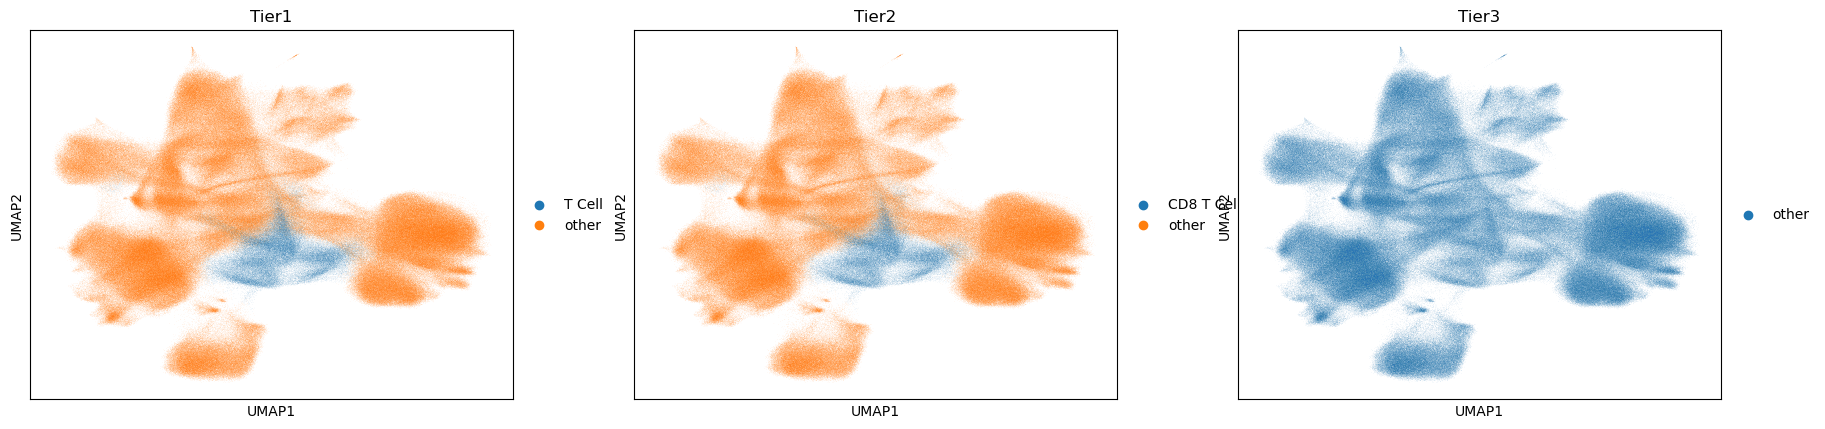

In [ ]:
sc.pl.umap(adata, color=['Tier1', 'Tier2', 'Tier3'])

In [ ]:
# adata.write_h5ad(f'{DATA_DIR}/adata.h5ad')